<a href="https://colab.research.google.com/github/komronbekqayumov/diabetes-prediction/blob/main/Diabet_kasalligini_bashorat_qilish_portfolio_uchun_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
url = 'https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/refs/heads/main/diabetes.csv'
df = pd.read_csv(url)


In [ ]:
cols_with_zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero_as_missing] = df[cols_with_zero_as_missing].replace(0, np.nan)


In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
conf_matrix = confusion_matrix(y_test, y_pred)


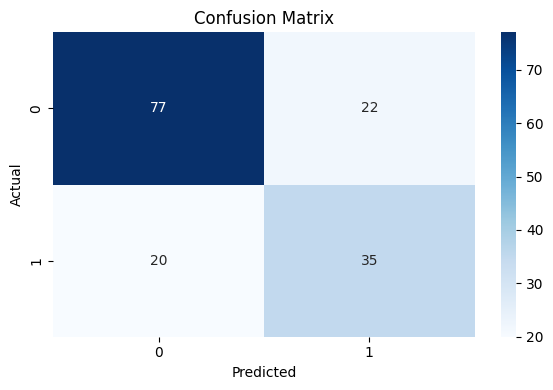

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


In [ ]:
accuracy, report, conf_matrix


(0.7272727272727273,
 {'0': {'precision': 0.7938144329896907,
   'recall': 0.7777777777777778,
   'f1-score': 0.7857142857142857,
   'support': 99.0},
  '1': {'precision': 0.6140350877192983,
   'recall': 0.6363636363636364,
   'f1-score': 0.625,
   'support': 55.0},
  'accuracy': 0.7272727272727273,
  'macro avg': {'precision': 0.7039247603544945,
   'recall': 0.7070707070707071,
   'f1-score': 0.7053571428571428,
   'support': 154.0},
  'weighted avg': {'precision': 0.7296075239645505,
   'recall': 0.7272727272727273,
   'f1-score': 0.7283163265306122,
   'support': 154.0}},
 array([[77, 22],
        [20, 35]]))

In [ ]:
comparison_df = pd.DataFrame({
    'Asl_Outcome': y_test.values,
    'Predict_qilingan': y_pred
})

# Birinchi 20 ta qiymatni ko‘rsatamiz
comparison_df.head(20)


,Asl_Outcome,Predict_qilingan
0,0,0
1,0,0
2,0,0
3,0,0
4,0,1
5,0,1
6,0,0
7,0,1
8,0,1
9,0,1


In [ ]:
comparison_df['Natija'] = np.where(comparison_df['Asl_Outcome'] == comparison_df['Predict_qilingan'], 'To‘g‘ri', 'Noto‘g‘ri')
comparison_df.head(20)


,Asl_Outcome,Predict_qilingan,Natija
0,0,0,To‘g‘ri
1,0,0,To‘g‘ri
2,0,0,To‘g‘ri
3,0,0,To‘g‘ri
4,0,1,Noto‘g‘ri
5,0,1,Noto‘g‘ri
6,0,0,To‘g‘ri
7,0,1,Noto‘g‘ri
8,0,1,Noto‘g‘ri
9,0,1,Noto‘g‘ri


In [ ]:
comparison_df['Natija'].value_counts()


,count
Natija,
To‘g‘ri,112
Noto‘g‘ri,42
